# Medical Imaging 101: How a Computer "Sees" Inside Your Body

### A hands-on lesson for curious high-school students

Have you ever wondered what an X-ray, CT, or PET scan really *is* on the inside of a computer?

The big secret of this whole lesson is one sentence:

> **A medical image is just a giant grid of numbers.**

That's it. The pretty grayscale pictures doctors look at are really just spreadsheets of numbers, where each number is the brightness of a tiny square. In this notebook we will load **three real 3D medical scans** of the same patient and play with them:

| File | What it is | Plain-English meaning |
|------|------------|------------------------|
| `CTres.nii.gz` | **CT scan** | An X-ray-based 3D photo. Bright = dense stuff (bone), dark = air. |
| `SUV.nii.gz` | **PET scan (SUV)** | Shows how *active* tissue is. Hot spots can be tumors. |
| `SEG.nii.gz` | **Segmentation** | A coloring-book outline: which voxels are tumor (1) vs not (0). |

**What you'll learn by the end:**
1. An image = an array of numbers (pixels / voxels)
2. What the pixel *values* mean (brightness, Hounsfield units, SUV)
3. What "binary" means in a segmentation mask (just 0s and 1s)
4. **Indexing & slicing**: how to grab one slice or one number out of the 3D block
5. **Cropping**: zooming into just the interesting part
6. Putting it together: counting tumor voxels and measuring real-world volume

No prior coding needed — just read each cell, then press **Shift + Enter** to run it. 🚀

## Step 0 — Install & import our tools

Python comes with "toolboxes" called **libraries**. We need three:
- **NumPy** — for working with grids of numbers (arrays)
- **nibabel** — knows how to read brain/body scan files (`.nii.gz`)
- **Matplotlib** — for drawing pictures

Run the cell below once. If a library is already installed, pip will just say so and move on.

In [1]:
# The leading ! lets us run an install command from inside the notebook.
# Safe to run more than once.
!pip install numpy nibabel matplotlib

In [2]:
import numpy as np                 # number-grid toolbox
import nibabel as nib             # reads medical scan files
import matplotlib.pyplot as plt   # draws pictures

print("All tools loaded. Ready to go!")

All tools loaded. Ready to go!


## Step 1 — Load the three scans

Loading a scan happens in two parts:
1. `nib.load(...)` opens the file (this part is fast, it just peeks).
2. `.get_fdata()` actually pulls all the numbers into a NumPy array we can play with.

Think of it like opening a book vs. actually reading every page.

In [6]:
# Where the files live (relative to this notebook)
ct_path  = "/rsrch1/ip/msalehjahromi/educational/data/CTres.nii.gz"   # CT scan
suv_path = "/rsrch1/ip/msalehjahromi/educational/data/SUV.nii.gz"     # PET / SUV scan
seg_path = "/rsrch1/ip/msalehjahromi/educational/data/SEG.nii.gz"     # tumor segmentation mask

# Open the files
ct_img  = nib.load(ct_path)
suv_img = nib.load(suv_path)
seg_img = nib.load(seg_path)

# Pull the numbers into arrays
ct  = ct_img.get_fdata()
suv = suv_img.get_fdata()
seg = seg_img.get_fdata()

print("Loaded all three scans!")

Loaded all three scans!


## Step 2 — An image is just a big block of numbers

Every array has a **shape**: how many numbers it has along each direction.

A normal photo is **2D** (height × width). A CT or PET scan is **3D** — it's a stack of many 2D slices, like a loaf of sliced bread. So its shape has *three* numbers: (rows × columns × slices).

Each tiny cube in a 3D medical image is called a **voxel** (a 3D "pixel").

In [7]:
print("CT  shape:", ct.shape)
print("SUV shape:", suv.shape)
print("SEG shape:", seg.shape)

# How many numbers is that in total?
print("\nThe CT scan alone contains", ct.size, "numbers!")
print("That's about", round(ct.size / 1_000_000, 1), "million voxels.")

CT  shape: (400, 400, 284)
SUV shape: (400, 400, 284)
SEG shape: (400, 400, 284)

The CT scan alone contains 45440000 numbers!
That's about 45.4 million voxels.


### Let's actually *look* at some of the raw numbers

Below we pull out a tiny 8×8 corner from one slice of the CT and print it as a table of numbers. **This is what the computer really stores** — there is no "picture", only numbers.

In [8]:
# Pick the middle slice (we'll explain this indexing in Step 5!)
middle_slice = ct.shape[2] // 2

# Grab a small 8x8 patch of numbers from the center of that slice
r = ct.shape[0] // 2
c = ct.shape[1] // 2
patch = ct[r:r+8, c:c+8, middle_slice]

print("An 8x8 patch of raw CT numbers:\n")
print(np.round(patch).astype(int))

An 8x8 patch of raw CT numbers:

[[ 144  118   43  -72  -84  -79  -79  -66]
 [  56  -39  -57  -68 -103  -68  -45   -5]
 [ -73 -125  -67  -66 -116  -12    7   48]
 [ -42  -65  -80  -53  -89   21   49   77]
 [  35  -71  -91  -30  -41   13   63   31]
 [ -81  -74  -71  -77  -23   72   42    7]
 [ -67  -83 -100    2   30   32   74   27]
 [ -72  -84  -77   -8   -3   13   26   11]]


### Now turn those same numbers into a picture

Matplotlib's `imshow` reads a grid of numbers and paints each number as a shade of gray: **small number = dark, big number = bright.** Watch the exact same 8×8 numbers become an 8×8 image.

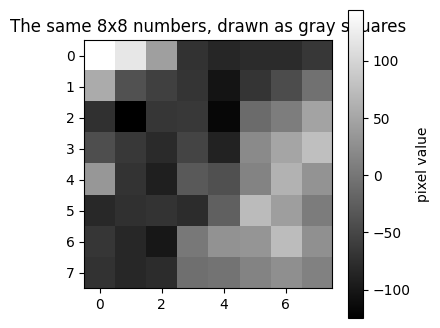

In [9]:
plt.figure(figsize=(4, 4))
plt.imshow(patch, cmap="gray")
plt.title("The same 8x8 numbers, drawn as gray squares")
plt.colorbar(label="pixel value")
plt.show()

## Step 3 — What do the pixel values *mean*?

Different scans use different number scales.

**CT scans** use **Hounsfield Units (HU)** — a scale based on physics:
- Air ≈ **-1000** (very negative, shows up black)
- Fat ≈ -100
- Water = **0**
- Soft tissue / muscle ≈ +40
- Bone ≈ **+400 to +1000** (very bright)

So just by reading a number, you can guess what material it is! Let's check the range of values in our CT.

In [10]:
print("CT  min value:", round(ct.min()), " (most likely air)")
print("CT  max value:", round(ct.max()), " (most likely dense bone or metal)")
print("CT  average  :", round(ct.mean()))

print("\nSUV min value:", round(suv.min(), 2))
print("SUV max value:", round(suv.max(), 2), "  <- a hot, very active spot")

CT  min value: -1297  (most likely air)
CT  max value: 3250  (most likely dense bone or metal)
CT  average  : -896

SUV min value: 0.0
SUV max value: 74.29   <- a hot, very active spot


### A histogram: counting how often each value appears

A **histogram** sorts all the numbers into bins and counts them — like sorting candy by color and counting each pile. The tall peaks tell us which kinds of tissue are most common in the scan.

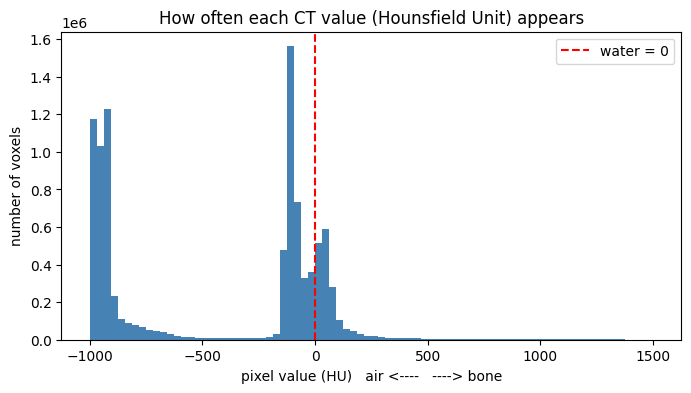

In [11]:
plt.figure(figsize=(8, 4))
# .ravel() flattens the 3D block into one long list of numbers
plt.hist(ct.ravel(), bins=80, range=(-1000, 1500), color="steelblue")
plt.title("How often each CT value (Hounsfield Unit) appears")
plt.xlabel("pixel value (HU)   air <----   ----> bone")
plt.ylabel("number of voxels")
plt.axvline(0, color="red", linestyle="--", label="water = 0")
plt.legend()
plt.show()

## Step 4 — Looking at a full slice (and "windowing")

Let's display a whole middle slice of the body. We'll also learn **windowing**: doctors pick a *range* of values to show, so the tissue they care about looks clear. It's just like adjusting brightness and contrast on a TV.

*(Note: we use `.T` and `origin='lower'` just to rotate the image so the body appears upright.)*

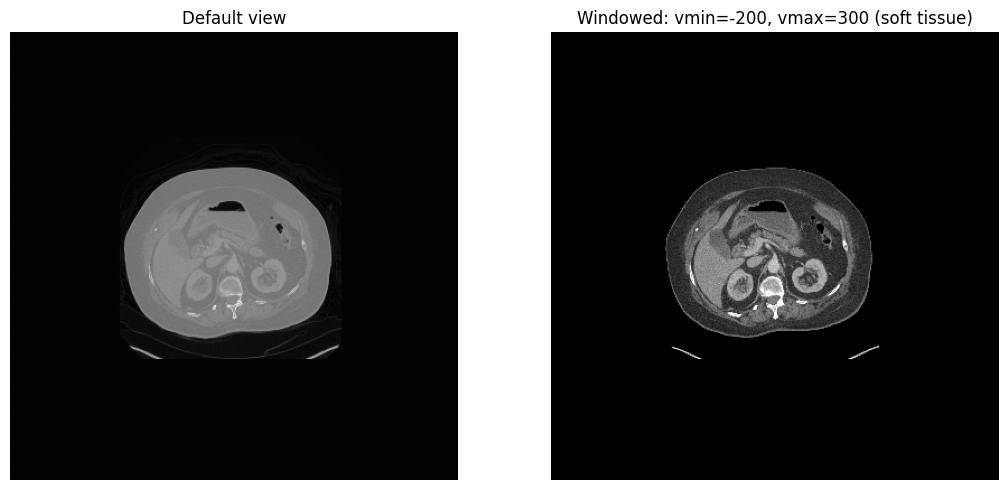

In [12]:
z = ct.shape[2] // 2          # middle slice number
ct_slice = ct[:, :, z]        # grab that 2D slice

fig, axes = plt.subplots(1, 2, figsize=(11, 5))

# Left: no windowing (auto). Right: a 'soft tissue' window.
axes[0].imshow(ct_slice.T, cmap="gray", origin="lower")
axes[0].set_title("Default view")
axes[0].axis("off")

axes[1].imshow(ct_slice.T, cmap="gray", origin="lower", vmin=-200, vmax=300)
axes[1].set_title("Windowed: vmin=-200, vmax=300 (soft tissue)")
axes[1].axis("off")

plt.tight_layout()
plt.show()

**Try it yourself:** change `vmin` and `vmax` above. Set `vmin=200, vmax=1000` to make **bones** pop out. The numbers didn't change — only how we *display* them did!

## Step 5 — Indexing and slicing (the most important coding skill!)

**Indexing** = picking out specific numbers from the array using square brackets `[ ]`.

Our array has 3 directions (axes), so we use 3 positions separated by commas: `array[row, column, slice]`.

Key ideas:
- Counting **starts at 0**, not 1. The first item is `[0]`.
- A single number picks **one** value: `ct[100, 100, 50]`.
- A colon `:` means **"give me everything along this axis."**
- `start:stop` picks a **range** (a slice), e.g. `10:20` is items 10 up to (but not including) 20.

In [13]:
# Pick ONE single voxel and read its number
one_voxel = ct[150, 150, z]
print("The value of one single voxel ct[150, 150, z] is:", round(one_voxel))

# Use ':' to grab a whole 2D slice (every row, every column, one slice)
a_slice = ct[:, :, z]
print("\nShape when we slice one z-plane ct[:, :, z]:", a_slice.shape, "(this is 2D)")

# Grab a single column of numbers going through the body
a_line = ct[150, :, z]
print("Shape of a single line ct[150, :, z]:", a_line.shape, "(this is 1D)")

The value of one single voxel ct[150, 150, z] is: 7

Shape when we slice one z-plane ct[:, :, z]: (400, 400) (this is 2D)
Shape of a single line ct[150, :, z]: (400,) (this is 1D)


### The same body, three different directions

Because the scan is 3D, we can slice it along any of the three axes to get **axial** (top-down), **coronal** (front), and **sagittal** (side) views. Notice how *which* axis we put the colon on changes the view.

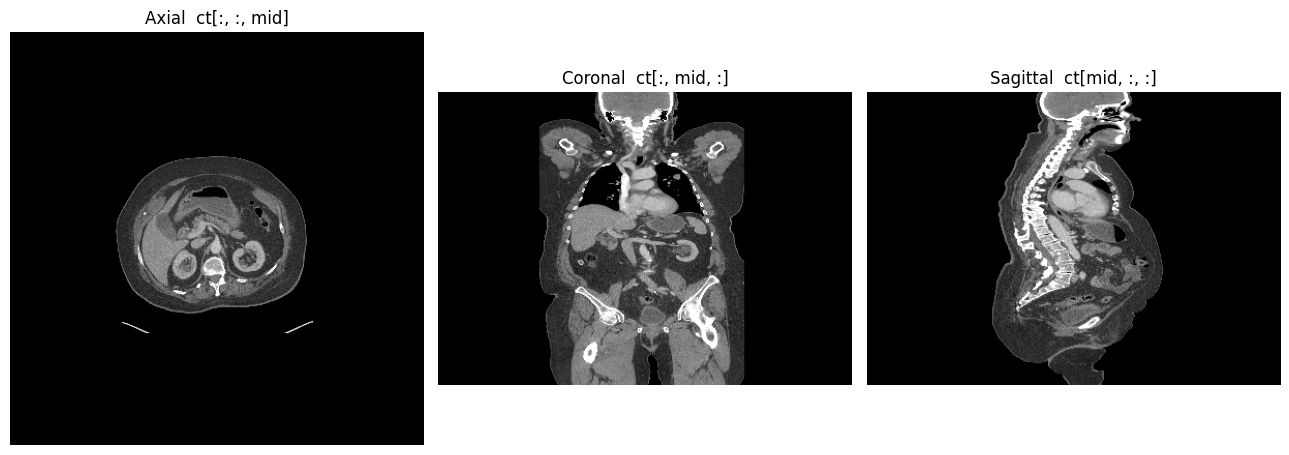

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(13, 5))

# Axial: fix the 3rd axis (slice through height)
axes[0].imshow(ct[:, :, ct.shape[2]//2].T, cmap="gray", origin="lower", vmin=-200, vmax=300)
axes[0].set_title("Axial  ct[:, :, mid]")

# Coronal: fix the 2nd axis
axes[1].imshow(ct[:, ct.shape[1]//2, :].T, cmap="gray", origin="lower", vmin=-200, vmax=300)
axes[1].set_title("Coronal  ct[:, mid, :]")

# Sagittal: fix the 1st axis
axes[2].imshow(ct[ct.shape[0]//2, :, :].T, cmap="gray", origin="lower", vmin=-200, vmax=300)
axes[2].set_title("Sagittal  ct[mid, :, :]")

for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

## Step 6 — The PET / SUV scan: showing activity

The PET scan measures **SUV** (Standardized Uptake Value). Patients drink a sugar that glows on the scan. Busy cells (like many tumors) eat lots of sugar, so they light up as **hot spots**.

We'll use a colorful "hot" colormap so high activity looks bright/yellow.

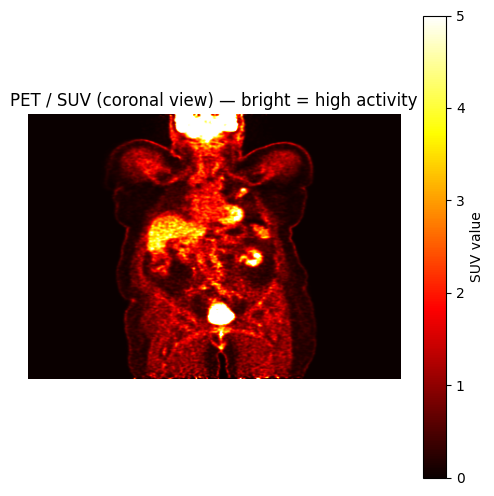

In [15]:
zc = suv.shape[2] // 2

plt.figure(figsize=(6, 6))
# Max-intensity-ish view: show the brightest activity, capped at SUV=5 for contrast
plt.imshow(suv[:, suv.shape[1]//2, :].T, cmap="hot", origin="lower", vmin=0, vmax=5)
plt.title("PET / SUV (coronal view) — bright = high activity")
plt.colorbar(label="SUV value")
plt.axis("off")
plt.show()

## Step 7 — Segmentation: what "binary" means

The segmentation mask (`SEG`) is special. Instead of many different values, it usually contains **only two**:
- **0** = "this voxel is NOT the thing we marked" (background)
- **1** = "this voxel IS the thing" (tumor)

Two possible values — that's what **binary** means ("bi" = two). It's like a yes/no answer for every single voxel: *is this tumor? yes (1) or no (0)*.

Let's prove it by listing every unique value in the mask.

In [16]:
unique_values = np.unique(seg)
print("Every unique value found in the segmentation:", unique_values)
print("\nSee? Just two values — that's why we call it BINARY.")

# Count how many voxels are marked as tumor (value == 1)
num_tumor = np.sum(seg == 1)
num_total = seg.size
print("\nTumor voxels (the 1s):", num_tumor)
print("Background voxels (the 0s):", num_total - num_tumor)
print("Tumor is", round(100 * num_tumor / num_total, 4), "% of the whole scan.")

Every unique value found in the segmentation: [0. 1.]

See? Just two values — that's why we call it BINARY.

Tumor voxels (the 1s): 3391
Background voxels (the 0s): 45436609
Tumor is 0.0075 % of the whole scan.


### Comparing a value with `==` makes a NEW binary mask

This is a superpower of NumPy. When you write `seg == 1`, the computer checks *every voxel at once* and answers True/False. True acts like 1 and False acts like 0 — instantly giving us a fresh binary mask. We can do the same trick on the CT to find, say, all the bone.

bone_mask is made of True/False values:
  number of bone voxels: 136375
  type of values inside: bool


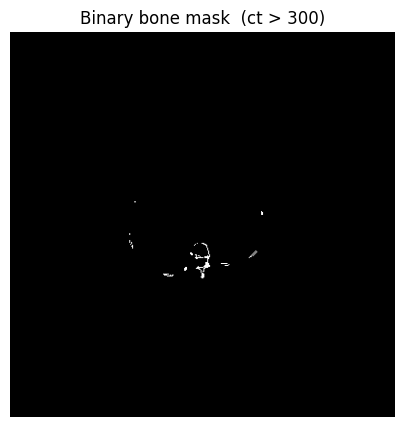

In [17]:
# Make a binary 'bone mask' from the CT: True where value > 300 (dense)
bone_mask = ct > 300

print("bone_mask is made of True/False values:")
print("  number of bone voxels:", np.sum(bone_mask))
print("  type of values inside:", bone_mask.dtype)

# Show the bone mask for the middle slice
plt.figure(figsize=(5, 5))
plt.imshow(bone_mask[:, :, z].T, cmap="gray", origin="lower")
plt.title("Binary bone mask  (ct > 300)")
plt.axis("off")
plt.show()

## Step 8 — Find the tumor and overlay it

Let's find which slice contains the most tumor, then draw the tumor outline on top of the CT and PET. Overlaying lets us see *where* the marked region sits inside the body.

In [18]:
# For each slice, count tumor voxels; pick the slice with the most.
tumor_per_slice = np.sum(seg == 1, axis=(0, 1))
best_z = int(np.argmax(tumor_per_slice))
print("The slice with the most tumor is slice #", best_z)
print("It has", int(tumor_per_slice[best_z]), "tumor voxels.")

The slice with the most tumor is slice # 200
It has 248 tumor voxels.


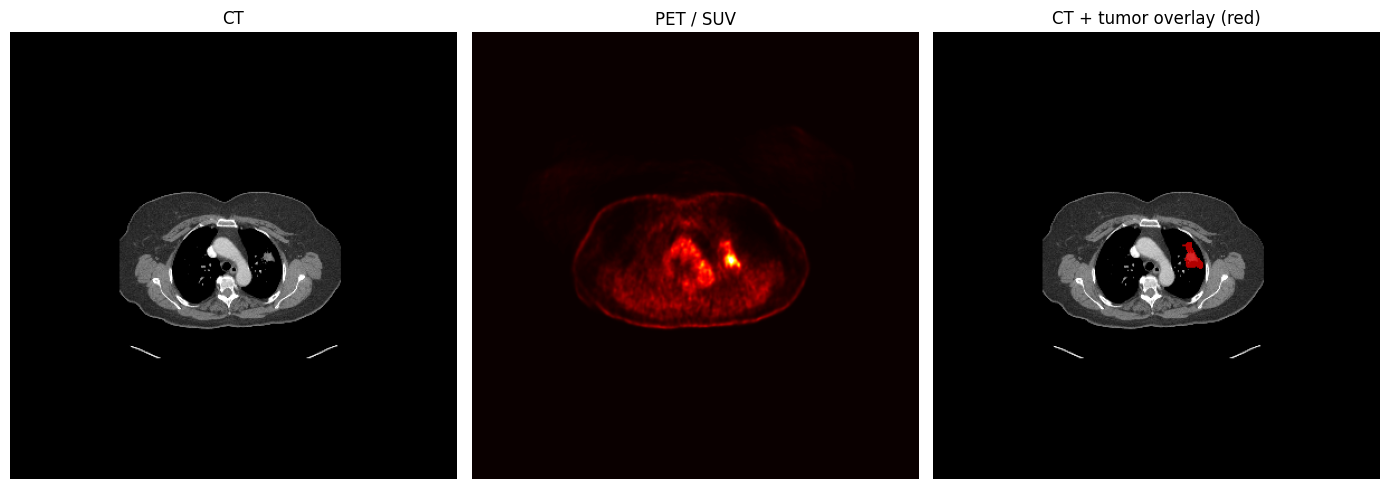

In [19]:
# Pull out the matching slices
ct_s  = ct[:, :, best_z].T
suv_s = suv[:, :, best_z].T
seg_s = seg[:, :, best_z].T

# Hide background (0) so only the tumor (1) is colored in the overlay
seg_overlay = np.ma.masked_where(seg_s == 0, seg_s)

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

axes[0].imshow(ct_s, cmap="gray", origin="lower", vmin=-200, vmax=300)
axes[0].set_title("CT")

axes[1].imshow(suv_s, cmap="hot", origin="lower", vmin=0, vmax=5)
axes[1].set_title("PET / SUV")

axes[2].imshow(ct_s, cmap="gray", origin="lower", vmin=-200, vmax=300)
axes[2].imshow(seg_overlay, cmap="autumn", origin="lower", alpha=0.7)
axes[2].set_title("CT + tumor overlay (red)")

for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

## Step 9 — Cropping: zoom into just the tumor

**Cropping** means cutting out a smaller rectangle from the big image — exactly like cropping a photo on your phone. We do it with slicing: `array[row_start:row_stop, col_start:col_stop]`.

We'll automatically find the box around the tumor and crop all three images to it. This is super common in real AI research: we throw away the boring background and keep only the interesting part.

Tumor is roughly inside the box:
  rows 203 to 261
  cols 168 to 231


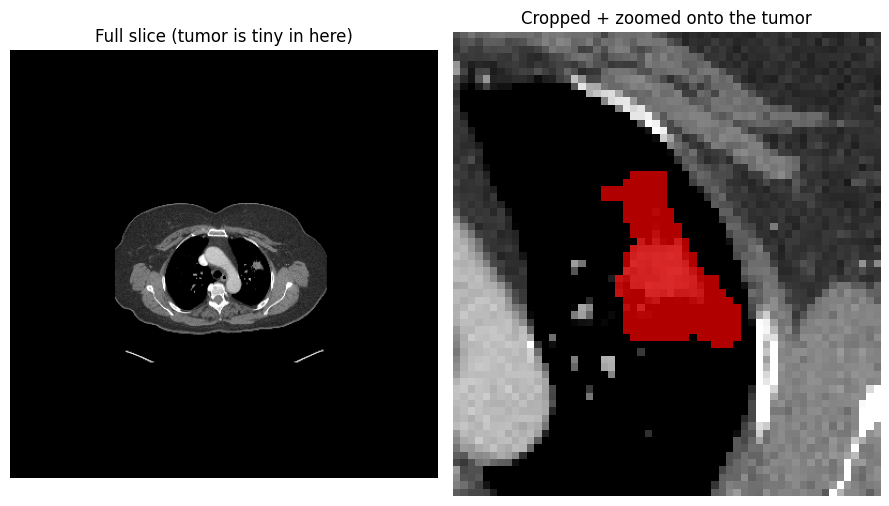

In [20]:
# np.where finds the row/col positions where the tumor exists on this slice
rows, cols = np.where(seg[:, :, best_z] == 1)

pad = 20  # add a little margin so we can see around the tumor
r0, r1 = rows.min() - pad, rows.max() + pad
c0, c1 = cols.min() - pad, cols.max() + pad

print("Tumor is roughly inside the box:")
print("  rows", r0, "to", r1)
print("  cols", c0, "to", c1)

# Crop using slicing
ct_crop  = ct[r0:r1, c0:c1, best_z].T
seg_crop = seg[r0:r1, c0:c1, best_z].T
seg_crop_overlay = np.ma.masked_where(seg_crop == 0, seg_crop)

fig, axes = plt.subplots(1, 2, figsize=(9, 5))
axes[0].imshow(ct[:, :, best_z].T, cmap="gray", origin="lower", vmin=-200, vmax=300)
axes[0].set_title("Full slice (tumor is tiny in here)")
axes[0].axis("off")

axes[1].imshow(ct_crop, cmap="gray", origin="lower", vmin=-200, vmax=300)
axes[1].imshow(seg_crop_overlay, cmap="autumn", origin="lower", alpha=0.7)
axes[1].set_title("Cropped + zoomed onto the tumor")
axes[1].axis("off")

plt.tight_layout()
plt.show()

## Step 10 — From counting voxels to real-world size

Here's the magic that makes medical imaging *useful*: each voxel represents a real physical cube of a known size (stored in the file's header). If we know the size of one voxel, we can turn a simple **count** into a real **volume in milliliters** — something a doctor can act on.

1. Count the tumor voxels (the 1s).
2. Multiply by the real volume of one voxel.
3. Convert mm³ to mL (1 mL = 1000 mm³).

In [21]:
# The header tells us the real size (in mm) of one voxel along each axis
voxel_size_mm = seg_img.header.get_zooms()
print("One voxel measures", voxel_size_mm, "mm (x, y, z)")

# Volume of a single voxel = length x width x height
one_voxel_mm3 = voxel_size_mm[0] * voxel_size_mm[1] * voxel_size_mm[2]
print("So one voxel is", round(one_voxel_mm3, 2), "cubic millimeters.")

# Count tumor voxels and convert to a real volume
tumor_voxels = np.sum(seg == 1)
tumor_mm3 = tumor_voxels * one_voxel_mm3
tumor_mL  = tumor_mm3 / 1000.0

print("\nTumor voxels:", int(tumor_voxels))
print("Tumor volume:", round(tumor_mm3, 1), "mm^3")
print("Tumor volume:", round(tumor_mL, 2), "mL  (about", round(tumor_mL, 1), "cm^3)")

One voxel measures (2.03642, 2.03642, 3.0) mm (x, y, z)
So one voxel is 12.44 cubic millimeters.

Tumor voxels: 3391
Tumor volume: 42187.5 mm^3
Tumor volume: 42.19 mL  (about 42.2 cm^3)


## 🎓 Your turn! Mini-challenges

Now that you've seen how it works, try editing the code yourself. Make a new code cell (press **B**) and try these:

1. **Different slice:** Display CT slice number 100 instead of the middle one.
2. **Different window:** Show the CT with `vmin=200, vmax=1000` to make bone glow. What disappears?
3. **Make your own mask:** Create `air_mask = ct < -500` and display it. What part of the picture is "air"?
4. **Average tumor activity:** Use `suv[seg == 1].mean()` to find the average SUV *inside* the tumor. Is it higher than the whole-body average `suv.mean()`?
5. **Biggest hot spot:** Find the maximum SUV value with `suv.max()`. Tumors are often the hottest spot — is it inside the segmentation?

Below is a starter cell for challenge #4 — run it and see!

In [22]:
# Challenge #4: compare activity inside the tumor vs. the whole body
avg_in_tumor = suv[seg == 1].mean()
avg_whole    = suv.mean()

print("Average SUV inside the tumor:", round(avg_in_tumor, 2))
print("Average SUV in the whole scan:", round(avg_whole, 2))
print("\nThe tumor is about", round(avg_in_tumor / avg_whole, 1),
      "times more active than average tissue!")

Average SUV inside the tumor: 2.46
Average SUV in the whole scan: 0.13

The tumor is about 19.3 times more active than average tissue!


## 🧠 What you learned

- A medical image is **just a grid of numbers** (pixels in 2D, voxels in 3D).
- The **value** of each number has meaning: CT uses Hounsfield Units (air ≈ -1000, bone ≈ +1000), PET uses SUV (high = active).
- **Windowing** changes how we *display* numbers without changing the numbers themselves.
- **Indexing & slicing** with `[ ]` and `:` lets us grab single voxels, lines, slices, or sub-blocks.
- A **binary** segmentation mask is only 0s and 1s — a yes/no label for every voxel.
- **Cropping** is just slicing to keep the interesting region.
- Counting voxels + knowing voxel size = **real measurements** doctors can use.

You just did the same core steps that real medical-imaging AI researchers do every day. Nice work! 🎉